<a href="https://colab.research.google.com/github/BryanHinostroza/lab12-bh/blob/develop/LAB12_HINOSTROZA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO 12: DISTRIBUCIONES DE PROBABILIDAD A PRIORI Y POSTERIORI

Integrantes:

*   HINOSTROZA MARTINEZ, Bryan Jesus
*   GUTIERREZ GARCIA, Angela Belen

a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes,  
tratamiento de outliers a nivel univariado y multivariado, y balanceo de clases.

Cargar Librerías Básicas

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

Cargar el Dataset

In [2]:
# Cargar el dataset
df = pd.read_csv('obesidad.csv')

# Visualizar las primeras filas
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


 Análisis de Datos Faltantes

In [6]:
# Ver cantidad de valores faltantes por columna
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


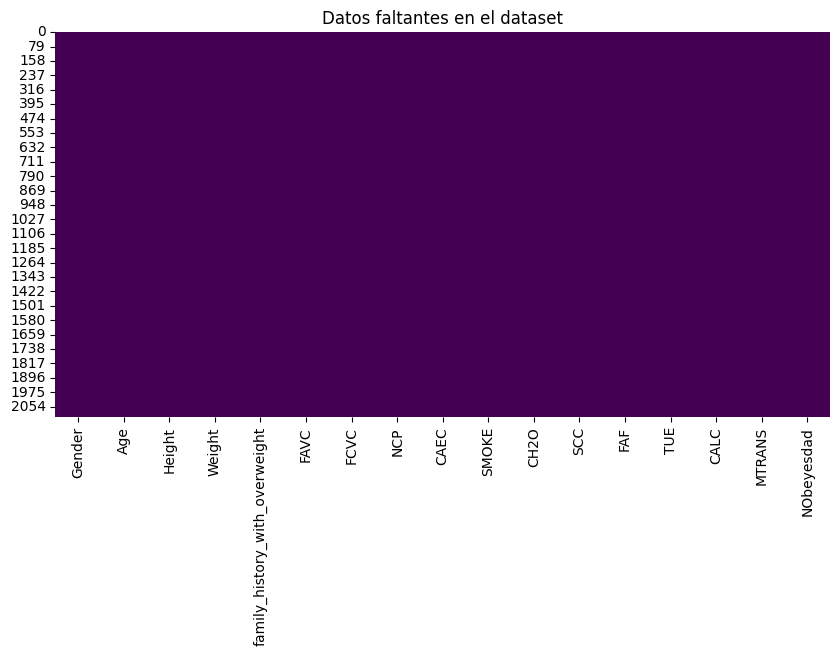

In [5]:
# También puedes visualizarlo gráficamente
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Datos faltantes en el dataset')
plt.show()

Tratamiento de Outliers

Visualización de outliers

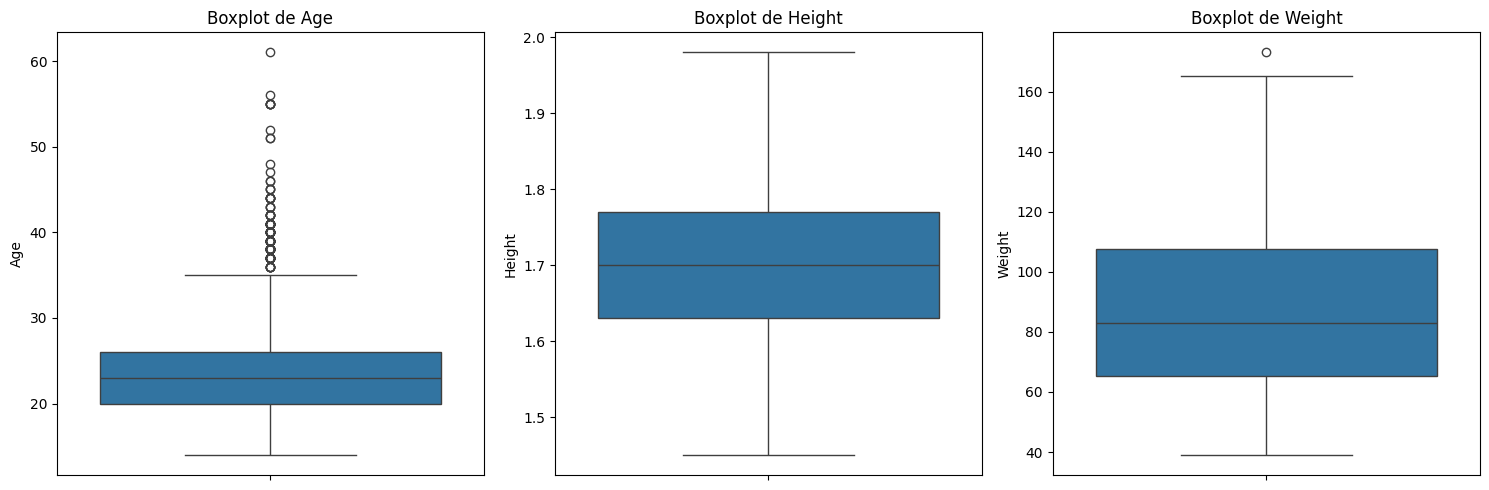

In [7]:
# Listado de variables numéricas
num_vars = ['Age', 'Height', 'Weight']

# Graficar boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(num_vars):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


Outliers univariado (IQR)

In [8]:
# Función para eliminar outliers univariados
def eliminar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[columna] >= lower_bound) & (df[columna] <= upper_bound)]

# Aplicar a Age, Height, Weight
df = eliminar_outliers(df, 'Age')
df = eliminar_outliers(df, 'Height')
df = eliminar_outliers(df, 'Weight')

Outliers multivariado (Isolation Forest)

In [9]:
from sklearn.ensemble import IsolationForest

# Definir modelo Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Entrenar en variables numéricas
outliers = iso_forest.fit_predict(df[['Age','Height','Weight']])

# Filtrar solo los datos NO outliers
df = df[outliers == 1]


Balanceo de clases (SMOTE)

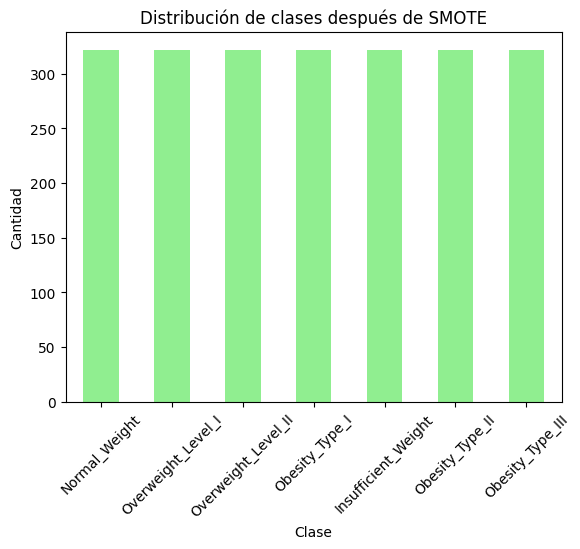

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Separar X e y
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Si X tiene columnas categóricas (como Gender), asegúrate que estén codificadas antes del SMOTE
# Por ejemplo con LabelEncoder para todas las columnas categóricas:
cat_columns = X.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_columns:
    X[col] = le.fit_transform(X[col])

# Aplicar SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Ver distribución después de SMOTE
pd.Series(y_res).value_counts().plot(kind='bar', color='lightgreen')
plt.title('Distribución de clases después de SMOTE')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

b. Convierta las variables categóricas a dummies por medio de la función ‘OneHotEncoder’ de la
librería ‘category_encoders’ la cual debe ser previamente instalada mediante la sentencia ‘!pip
install category-encoders’.

OneHotEncoder de category_encoders

In [11]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 6.2 MB/s eta 0:00:00


In [12]:
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

Convertir variables categóricas a dummies

In [13]:
# Separar X e y nuevamente (por si SMOTE se usó antes o no)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

In [14]:
# Aplicar OneHotEncoder
encoder = ce.OneHotEncoder(use_cat_names=True)
X_encoded = encoder.fit_transform(X)

# Mostrar ejemplo del nuevo X
X_encoded.head()

,Gender_Female,Gender_Male,Age,Height,Weight,family_history_with_overweight_yes,family_history_with_overweight_no,FAVC_no,FAVC_yes,FCVC,...,TUE,CALC_no,CALC_Sometimes,CALC_Frequently,CALC_Always,MTRANS_Public_Transportation,MTRANS_Walking,MTRANS_Automobile,MTRANS_Motorbike,MTRANS_Bike
0,1,0,21,1.62,64.0,1,0,1,0,2,...,1,1,0,0,0,1,0,0,0,0
1,1,0,21,1.52,56.0,1,0,1,0,3,...,0,0,1,0,0,1,0,0,0,0
2,0,1,23,1.80,77.0,1,0,1,0,2,...,1,0,0,1,0,1,0,0,0,0
3,0,1,27,1.80,87.0,0,1,1,0,3,...,0,0,0,1,0,0,1,0,0,0
4,0,1,22,1.78,89.8,0,1,1,0,2,...,0,0,1,0,0,1,0,0,0,0


c. Separe los datos en entrenamiento (80%) y prueba (20%), realice un Naive Bayes mediante la
función ‘GaussianNB’ y ‘MultinomialNB’. Compare los accuracy para los resultados obtenidos y
diga con cuál de ellos se obtuvo un mejor desempeño.

In [15]:
# Separar en train y test (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)


Entrenar modelos Naive Bayes y comparar

GaussianNB

In [16]:
# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predicción
y_pred_gnb = gnb.predict(X_test)

# Accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Accuracy GaussianNB: {accuracy_gnb:.4f}')

Accuracy GaussianNB: 0.5530


MultinomialNB

In [17]:
# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# Predicción
y_pred_mnb = mnb.predict(X_test)

# Accuracy
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f'Accuracy MultinomialNB: {accuracy_mnb:.4f}')

Accuracy MultinomialNB: 0.6589


# Conclusión

In [18]:
if accuracy_gnb > accuracy_mnb:
    print("El modelo GaussianNB obtuvo un mejor desempeño.")
else:
    print("El modelo MultinomialNB obtuvo un mejor desempeño.")

El modelo MultinomialNB obtuvo un mejor desempeño.


# Fase de Testing

In [19]:
import unittest

class TestNaiveBayes(unittest.TestCase):
    def test_gaussian_nb_accuracy(self):
        # Queremos que al menos sea mejor que 0.50 (ejemplo razonable)
        self.assertGreaterEqual(accuracy_gnb, 0.50)

    def test_multinomial_nb_accuracy(self):
        # Queremos que al menos sea mejor que 0.50 (ejemplo razonable)
        self.assertGreaterEqual(accuracy_mnb, 0.50)

    def test_shapes(self):
        # Aseguramos que las predicciones tengan el mismo tamaño que y_test
        self.assertEqual(len(y_pred_gnb), len(y_test))
        self.assertEqual(len(y_pred_mnb), len(y_test))

# Ejecutar pruebas
unittest.main(argv=[''], verbosity=2, exit=False)

test_gaussian_nb_accuracy (__main__.TestNaiveBayes.test_gaussian_nb_accuracy) ... ok
test_multinomial_nb_accuracy (__main__.TestNaiveBayes.test_multinomial_nb_accuracy) ... ok
test_shapes (__main__.TestNaiveBayes.test_shapes) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.005s

OK
